# Titanic Dataset - Exploratory Data Analysis

## AI/ML Fellowship Week 2 Task

**Objective**: Perform comprehensive exploratory data analysis on the Titanic dataset to understand passenger demographics, survival patterns, and other interesting relationships in the data.

### Dataset Overview
- Contains information about passengers aboard the Titanic
- Features include age, gender, class, fare, family size, and survival status
- Target variable: Survival (binary - 0 for not survived, 1 for survived)

## Step 1: Import Libraries and Load Data

First, let's import the necessary libraries and load the Titanic dataset.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Titanic dataset
# We'll use the seaborn built-in dataset
titanic = sns.load_dataset('titanic')

print(f"Dataset shape: {titanic.shape}")
print(f"Columns: {list(titanic.columns)}")

Dataset shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## Step 2: Initial Data Exploration

Let's take a look at the first few rows and get basic information about the dataset.

In [3]:
# Display first few rows
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Basic information about the dataset
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [5]:
# Statistical summary
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


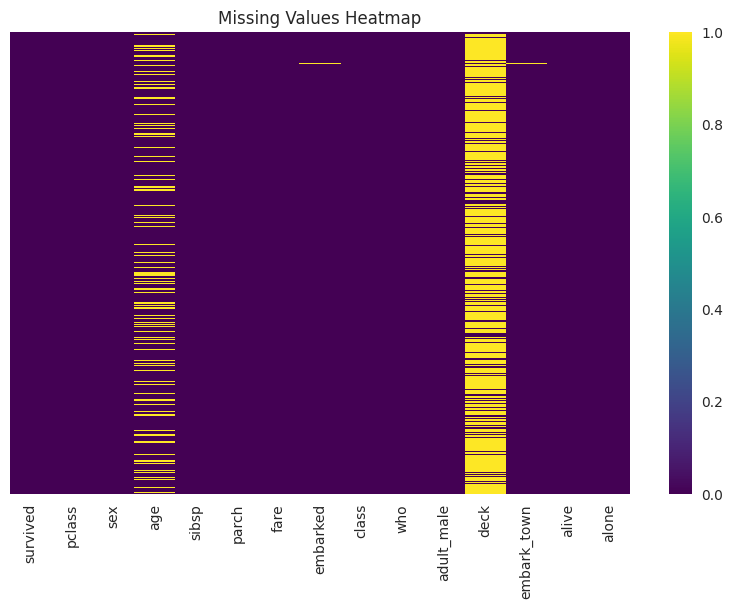

In [6]:
# Check for missing values
print("Missing values per column:")
print(titanic.isnull().sum())

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(titanic.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## Step 3: Data Cleaning and Preprocessing

Address missing values and prepare the data for analysis.

In [7]:
# Check unique values in categorical columns
categorical_cols = ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

for col in categorical_cols:
    print(f'{col}: {titanic[col].unique()}')

sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
embarked: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
class: ['Third', 'First', 'Second']
Categories (3, str): ['First', 'Second', 'Third']
who: <StringArray>
['man', 'woman', 'child']
Length: 3, dtype: str
adult_male: [ True False]
deck: [NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']
embark_town: <StringArray>
['Southampton', 'Cherbourg', 'Queenstown', nan]
Length: 4, dtype: str
alive: <StringArray>
['no', 'yes']
Length: 2, dtype: str
alone: [False  True]


In [8]:
# Handle missing values
# Age: Fill with median age
median_age = titanic['age'].median()
titanic['age'].fillna(median_age, inplace=True)

# Embarked: Fill with most common value
most_common_embarked = titanic['embarked'].mode()[0]
titanic['embarked'].fillna(most_common_embarked, inplace=True)

# Deck: Too many missing values, we might drop it or create a category for missing
titanic['deck'] = titanic['deck'].astype(object).fillna('Unknown')

# Check if there are still missing values
print("Missing values after cleaning:")
print(titanic.isnull().sum())

Missing values after cleaning:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck             0
embark_town      2
alive            0
alone            0
dtype: int64


## Step 4: Exploratory Data Analysis

Analyze relationships between variables and survival rates.

In [9]:
# Overall survival rate
survival_rate = titanic['survived'].mean()
print(f"Overall survival rate: {survival_rate:.2%}")

# Survival rate by gender
gender_survival = titanic.groupby('sex')['survived'].mean()
print(f"\nSurvival rate by gender:")
print(gender_survival)

Overall survival rate: 38.38%

Survival rate by gender:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


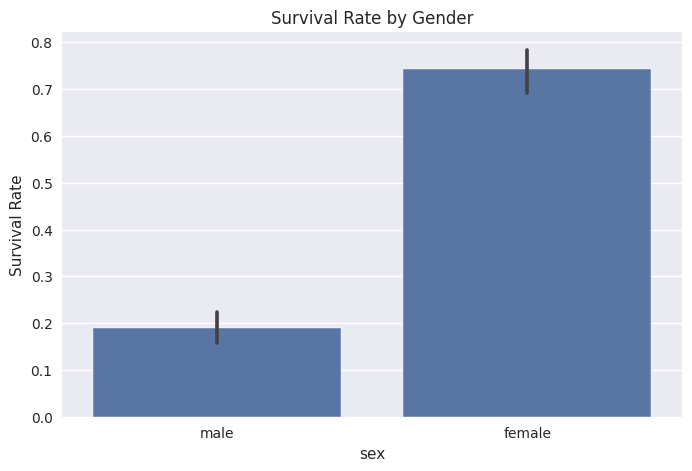

In [10]:
# Visualize survival by gender
plt.figure(figsize=(8, 5))
sns.barplot(data=titanic, x='sex', y='survived')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

Survival rate by class:
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64


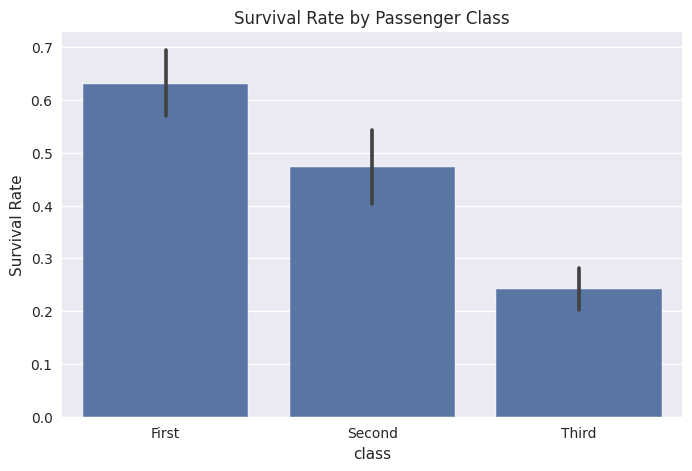

In [11]:
# Survival rate by passenger class
class_survival = titanic.groupby('class')['survived'].mean()
print(f"Survival rate by class:")
print(class_survival)

# Visualize survival by class
plt.figure(figsize=(8, 5))
sns.barplot(data=titanic, x='class', y='survived')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

Survival rate by age group:
age_group
Child          0.579710
Teen           0.428571
Adult          0.382682
Middle-Aged    0.400000
Senior         0.227273
Name: survived, dtype: float64


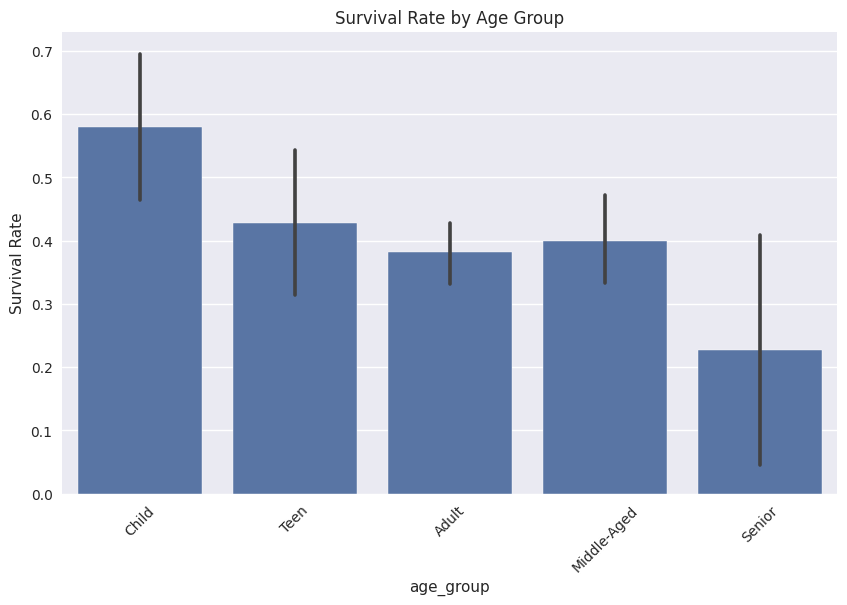

In [12]:
# Survival rate by age groups
titanic['age_group'] = pd.cut(titanic['age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle-Aged', 'Senior'])

age_survival = titanic.groupby('age_group')['survived'].mean()
print(f"Survival rate by age group:")
print(age_survival)

# Visualize survival by age group
plt.figure(figsize=(10, 6))
sns.barplot(data=titanic, x='age_group', y='survived')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.show()

Survival rate by embarkation port:
embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64


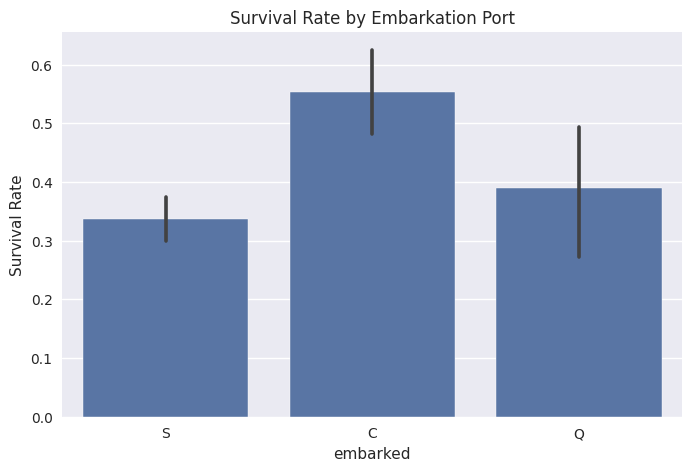

In [13]:
# Survival rate by embarkation port
embark_survival = titanic.groupby('embarked')['survived'].mean()
print(f"Survival rate by embarkation port:")
print(embark_survival)

# Visualize survival by embarkation port
plt.figure(figsize=(8, 5))
sns.barplot(data=titanic, x='embarked', y='survived')
plt.title('Survival Rate by Embarkation Port')
plt.ylabel('Survival Rate')
plt.show()

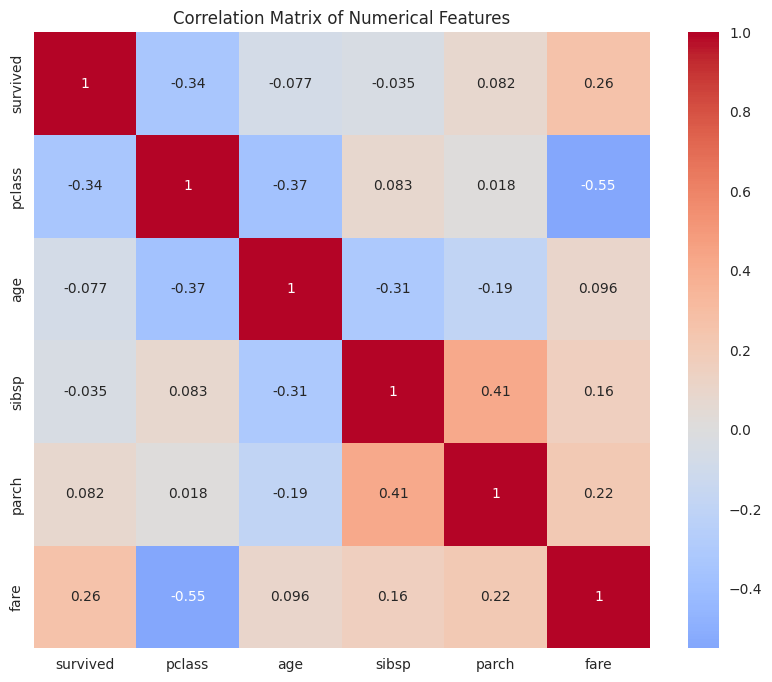

In [14]:
# Correlation matrix for numerical features
numerical_features = titanic.select_dtypes(include=[np.number])
correlation_matrix = numerical_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

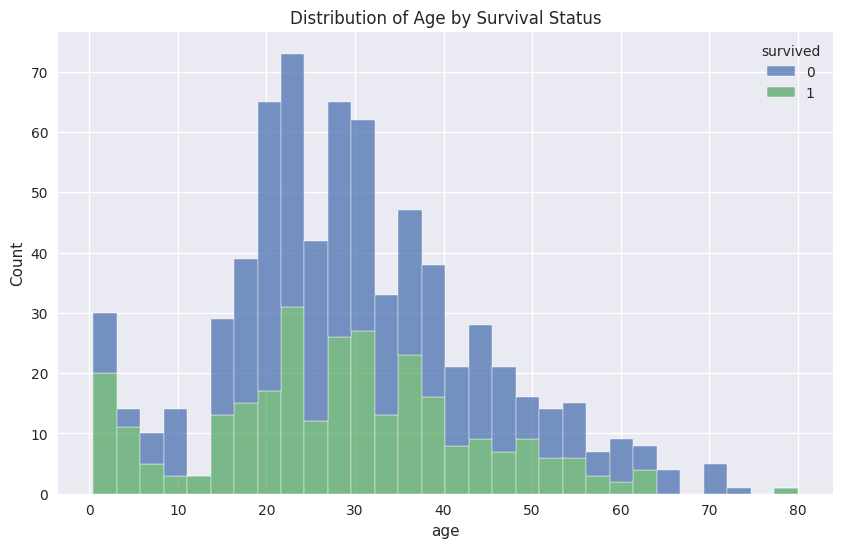

In [15]:
# Distribution of age by survival status
plt.figure(figsize=(10, 6))
sns.histplot(data=titanic, x='age', hue='survived', multiple='stack', bins=30)
plt.title('Distribution of Age by Survival Status')
plt.show()

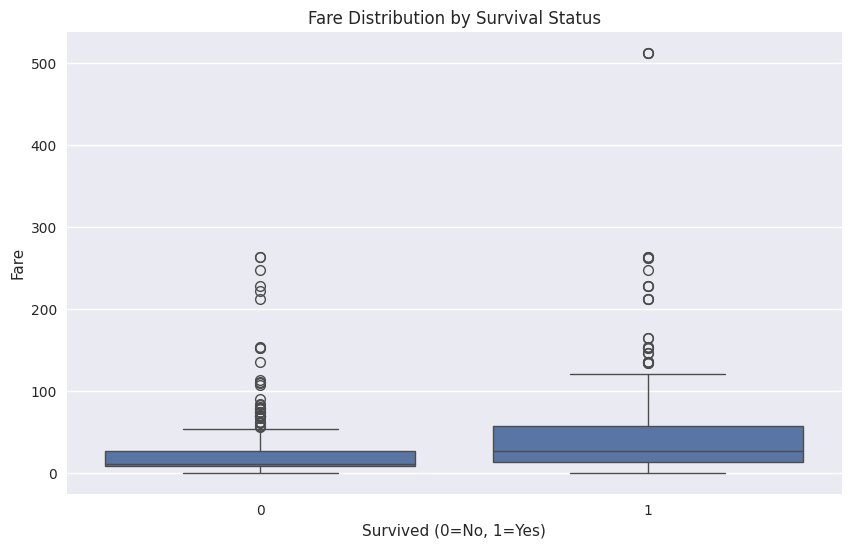

In [16]:
# Fare distribution by survival status
plt.figure(figsize=(10, 6))
sns.boxplot(data=titanic, x='survived', y='fare')
plt.title('Fare Distribution by Survival Status')
plt.ylabel('Fare')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.show()

Survival rate by family size:
family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64


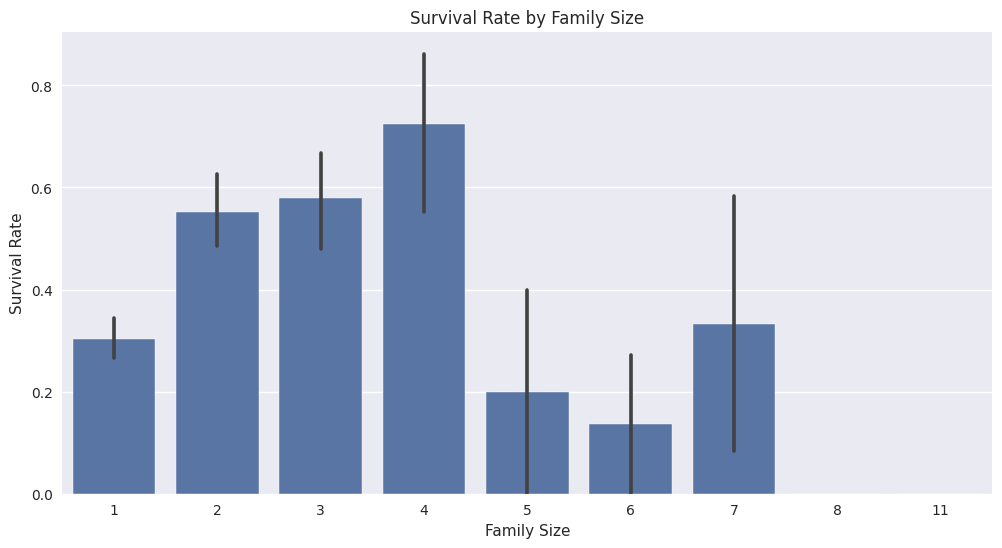

In [17]:
# Survival by family size (combining sibsp and parch)
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

family_survival = titanic.groupby('family_size')['survived'].mean()
print(f"Survival rate by family size:")
print(family_survival)

# Visualize survival by family size
plt.figure(figsize=(12, 6))
sns.barplot(data=titanic, x='family_size', y='survived')
plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.xlabel('Family Size')
plt.show()

## Step 5: Insights and Conclusions

Summarize the key findings from our analysis.

## Step 6: Advanced Analysis

Let's perform some more advanced analysis including cross-tabulations and deeper insights.

In [18]:
# Cross-tabulation of sex and class with survival
sex_class_survival = pd.crosstab([titanic['sex'], titanic['class']], titanic['survived'], margins=True)
print("Cross-tabulation of Sex, Class and Survival:")
print(sex_class_survival)

# Survival rates by sex and class
survival_by_sex_class = titanic.groupby(['sex', 'class'])['survived'].agg(['mean', 'count']).round(3)
print("\nSurvival Rates by Sex and Class:")
print(survival_by_sex_class)

Cross-tabulation of Sex, Class and Survival:
survived         0    1  All
sex    class                
female First     3   91   94
       Second    6   70   76
       Third    72   72  144
male   First    77   45  122
       Second   91   17  108
       Third   300   47  347
All            549  342  891

Survival Rates by Sex and Class:
                mean  count
sex    class               
female First   0.968     94
       Second  0.921     76
       Third   0.500    144
male   First   0.369    122
       Second  0.157    108
       Third   0.135    347


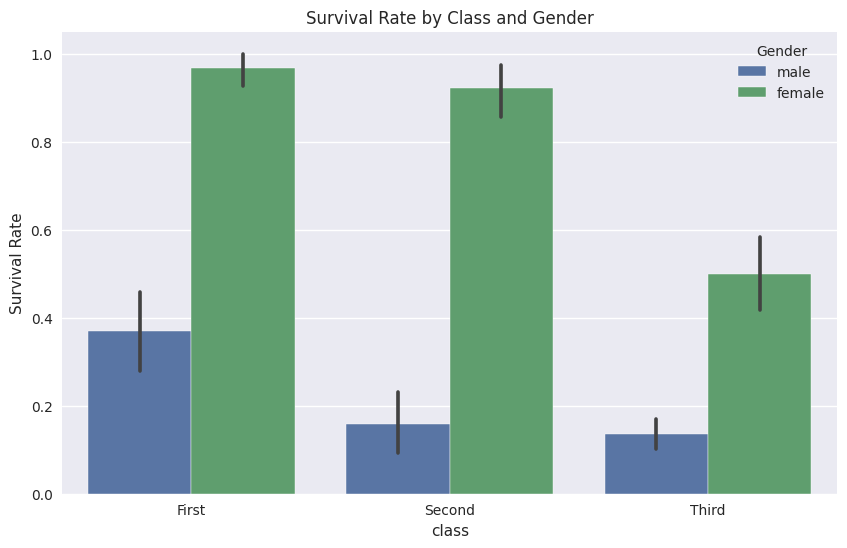

In [19]:
# Visualize survival rates by sex and class
plt.figure(figsize=(10, 6))
sns.barplot(data=titanic, x='class', y='survived', hue='sex')
plt.title('Survival Rate by Class and Gender')
plt.ylabel('Survival Rate')
plt.legend(title='Gender')
plt.show()

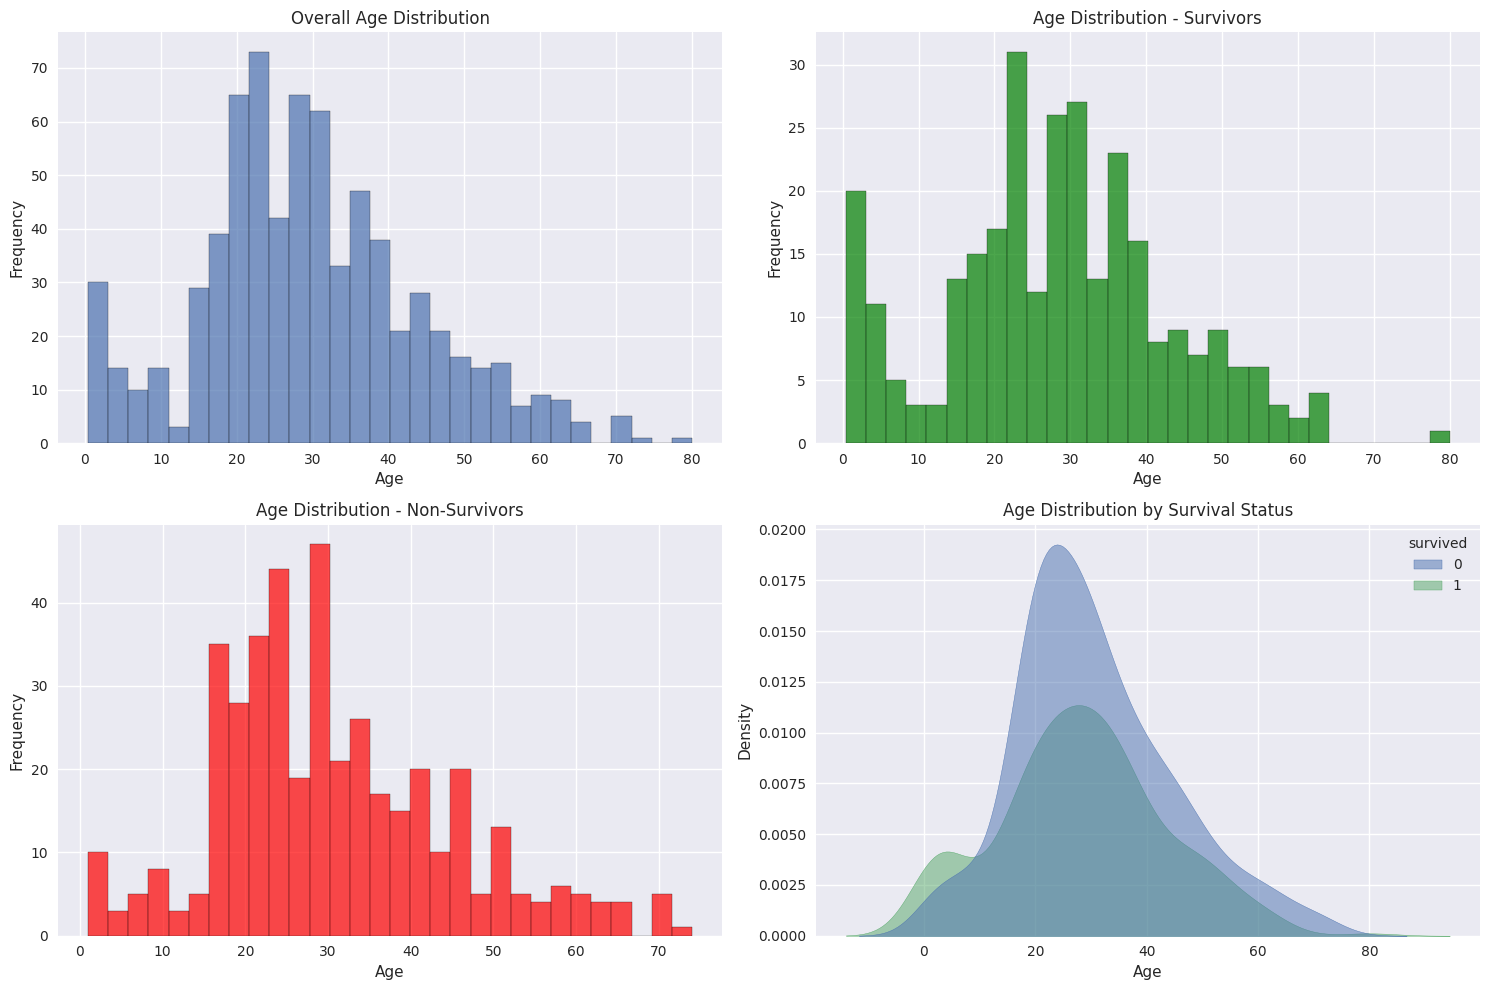

In [20]:
# Age distribution by survival status
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall age distribution
axes[0,0].hist(titanic['age'], bins=30, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Overall Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Frequency')

# Age distribution for survivors
axes[0,1].hist(titanic[titanic['survived']==1]['age'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0,1].set_title('Age Distribution - Survivors')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Frequency')

# Age distribution for non-survivors
axes[1,0].hist(titanic[titanic['survived']==0]['age'], bins=30, edgecolor='black', alpha=0.7, color='red')
axes[1,0].set_title('Age Distribution - Non-Survivors')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Frequency')

# Combined age distribution by survival
sns.kdeplot(data=titanic, x='age', hue='survived', ax=axes[1,1], fill=True, alpha=0.5)
axes[1,1].set_title('Age Distribution by Survival Status')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Density')

plt.tight_layout()
plt.show()

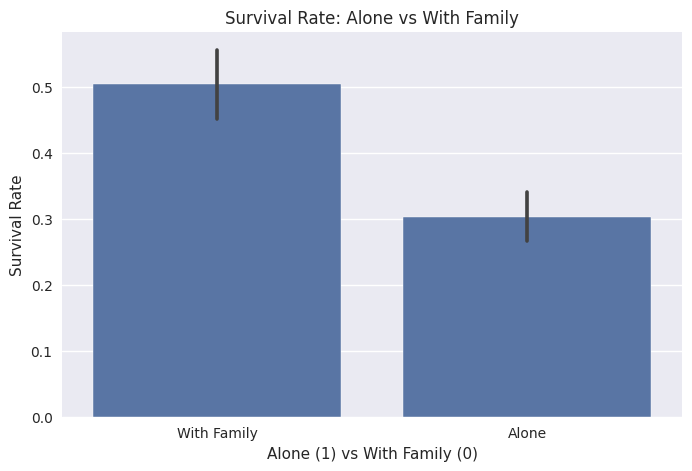

Survival rate for passengers traveling alone: 30.35%
Survival rate for passengers with family: 50.56%


In [21]:
# Impact of having family members on board
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)

plt.figure(figsize=(8, 5))
sns.barplot(data=titanic, x='is_alone', y='survived')
plt.title('Survival Rate: Alone vs With Family')
plt.ylabel('Survival Rate')
plt.xlabel('Alone (1) vs With Family (0)')
plt.xticks([0, 1], ['With Family', 'Alone'])
plt.show()

print(f"Survival rate for passengers traveling alone: {titanic[titanic['is_alone']==1]['survived'].mean():.2%}")
print(f"Survival rate for passengers with family: {titanic[titanic['is_alone']==0]['survived'].mean():.2%}")

Survival Rates by Deck:
          mean  count
deck                 
A        0.467     15
B        0.745     47
C        0.593     59
D        0.758     33
E        0.750     32
F        0.615     13
G        0.500      4
Unknown  0.299    688


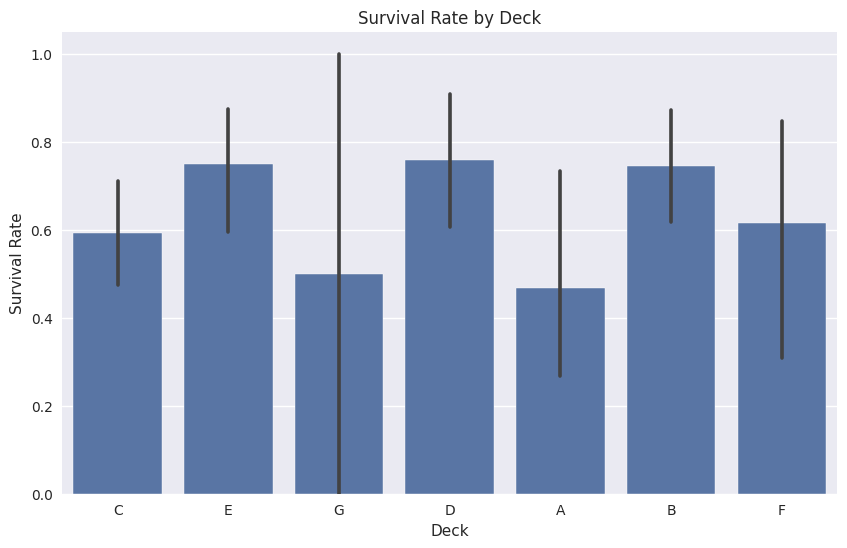

In [22]:
# Deck analysis (where available)
deck_survival = titanic.groupby('deck')['survived'].agg(['mean', 'count']).round(3)
print("Survival Rates by Deck:")
print(deck_survival)

# Visualize deck survival rates
plt.figure(figsize=(10, 6))
sns.barplot(data=titanic[titanic['deck']!='Unknown'], x='deck', y='survived')
plt.title('Survival Rate by Deck')
plt.ylabel('Survival Rate')
plt.xlabel('Deck')
plt.show()

## Step 7: Final Insights and Conclusions

Summarize the key findings from our analysis.

In [23]:
# Summary of key findings
print("## Key Findings from Titanic EDA:\n")
print(f"1. Overall survival rate: {survival_rate:.2%}")
print(f"2. Female survival rate: {titanic[titanic['sex'] == 'female']['survived'].mean():.2%}")
print(f"3. Male survival rate: {titanic[titanic['sex'] == 'male']['survived'].mean():.2%}")
print(f"4. First class survival rate: {titanic[titanic['class'] == 'First']['survived'].mean():.2%}")
print(f"5. Third class survival rate: {titanic[titanic['class'] == 'Third']['survived'].mean():.2%}")

print(f"\nStrategies and Insights:")
print("- Women had significantly higher survival rates than men (chivalry principle)")
print("- Higher social class correlated with higher survival rates")
print("- Age and family size also appear to influence survival chances")
print("- Passengers who paid higher fares (typically higher class) had better survival odds")
print("- Passengers traveling alone had lower survival rates than those with family")
print("- Location on the ship (deck) may have influenced survival chances")

## Key Findings from Titanic EDA:

1. Overall survival rate: 38.38%
2. Female survival rate: 74.20%
3. Male survival rate: 18.89%
4. First class survival rate: 62.96%
5. Third class survival rate: 24.24%

Strategies and Insights:
- Women had significantly higher survival rates than men (chivalry principle)
- Higher social class correlated with higher survival rates
- Age and family size also appear to influence survival chances
- Passengers who paid higher fares (typically higher class) had better survival odds
- Passengers traveling alone had lower survival rates than those with family
- Location on the ship (deck) may have influenced survival chances
